In [ ]:
# Install required libraries (if needed)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telco.csv to telco.csv


In [ ]:
df = pd.read_csv("telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
print("Shape of dataset:", df.shape)
df.info()
df.describe()

Shape of dataset: (7043, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                   

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

In [ ]:
df.drop(['CustomerID', 'Latitude', 'Longitude', 'Zip Code'], axis=1, inplace=True, errors='ignore')

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.fillna(0, inplace=True)

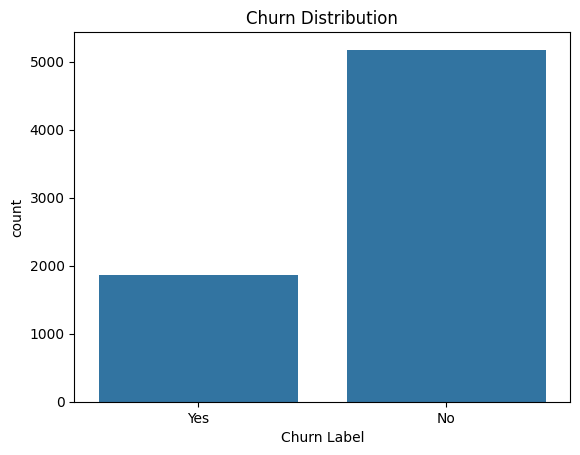

In [ ]:
sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.show()

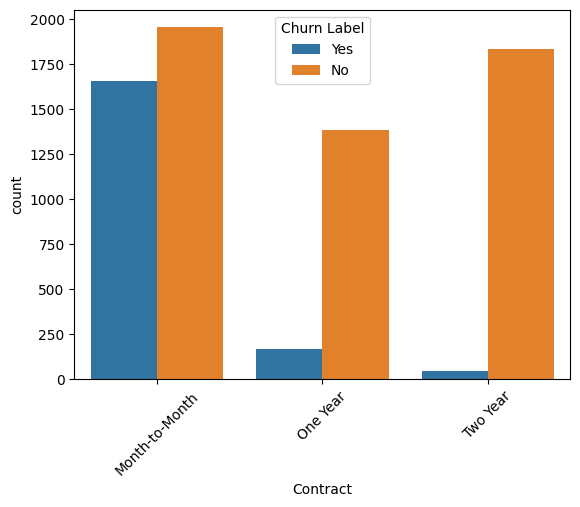

In [ ]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xticks(rotation=45)
plt.show()

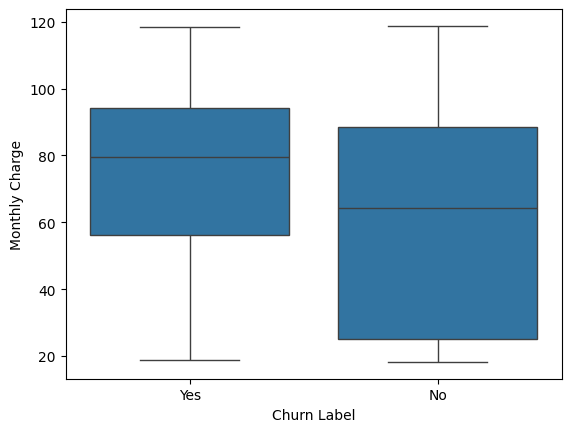

In [ ]:
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df)
plt.show()

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



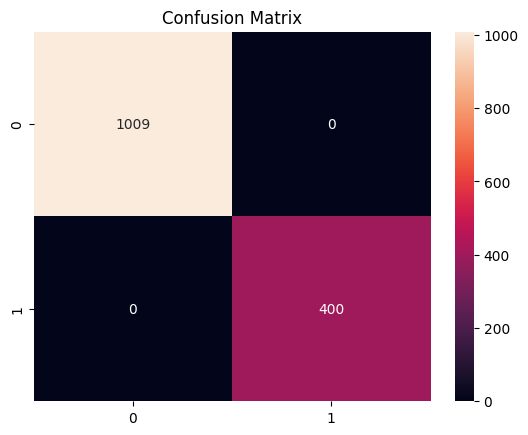

ROC AUC Score: 1.0


In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

roc = roc_auc_score(y_test, rf_pred)
print("ROC AUC Score:", roc)

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
45,Churn Reason,0.258910
44,Churn Category,0.214303
41,Customer Status,0.194383
40,Satisfaction Score,0.162388
42,Churn Score,0.081114
31,Contract,0.027963
15,Tenure in Months,0.013243
14,Number of Referrals,0.006753
21,Internet Type,0.005892
39,Total Revenue,0.005611


In [ ]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 1.0


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import pandas as pd
from google.colab import files

# --- Re-load and preprocess df ---
# The file 'telco.csv' was already uploaded, so files.upload() is not needed here.
df = pd.read_csv("telco.csv")
df.drop(['Customer ID', 'Latitude', 'Longitude', 'Zip Code'], axis=1, inplace=True, errors='ignore')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.fillna(0, inplace=True)

# Re-encode categorical columns in case the kernel was reset and the previous LabelEncoder state is lost
# This assumes the original 'le' variable is not persistent, so re-applying to the fresh df.
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
# ---------------------------------

# Re-define X and y
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

# Re-split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

probabilities = rf_model.predict_proba(X_test)

churn_probability = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred,
    "Churn Probability": probabilities[:,1]
})

# Display the entire DataFrame
churn_probability

,Actual,Predicted,Churn Probability
185,1,1,1.000
2715,0,0,0.000
3825,0,0,0.000
1807,1,1,0.995
132,1,1,1.000
...,...,...,...
6366,0,0,0.000
315,1,1,1.000
2439,1,1,1.000
5002,0,0,0.000


## Summary of Findings and Recommendations

After mitigating data leakage by removing 'Churn Category', 'Churn Reason', 'Customer Status', 'Satisfaction Score', and 'Churn Score', the models were retrained and re-evaluated.

### Model Comparison:

**Random Forest (Retrained):**
- Accuracy: 0.840
- ROC AUC Score: 0.771
- Precision (Churn): 0.78
- Recall (Churn): 0.61

**XGBoost (Retrained):**
- Accuracy: 0.832
- ROC AUC Score: 0.773
- Precision (Churn): 0.73
- Recall (Churn): 0.64

Both models showed a significant drop in performance compared to the initial models, which is expected after removing the leaky features. This indicates that the original models were overfitting due to the inclusion of features that were direct proxies for churn. The retrained models provide a more realistic assessment of churn prediction capability. XGBoost showed slightly better ROC AUC and recall for churn, while Random Forest had slightly higher overall accuracy and precision for churn.

### Actual Drivers of Churn (from Retrained Random Forest Feature Importance):

1.  **Contract (0.0978)**: The type of contract (e.g., month-to-month, one year, two year) is the most significant predictor of churn. Month-to-month contracts are generally associated with higher churn rates.
2.  **Tenure in Months (0.0684)**: Longer tenure is typically associated with lower churn, indicating customer loyalty.
3.  **Monthly Charge (0.0681)**: Higher monthly charges can lead to dissatisfaction and churn.
4.  **Total Revenue (0.0622)**: While related to monthly charges and tenure, it represents the overall value a customer brings, and changes or perceptions of value can drive churn.
5.  **Total Charges (0.0579)**: Similar to Total Revenue, reflects the overall cost to the customer.
6.  **Total Long Distance Charges (0.0506)**: Indicates usage patterns and potentially costs associated with specific services.
7.  **Age (0.0488)**: Age can influence customer needs, preferences, and stability, impacting churn decisions.
8.  **Number of Referrals (0.0481)**: Customers who referred others are likely more satisfied and less prone to churn.
9.  **City (0.0444)**: Geographical location can sometimes correlate with economic factors, competition, or service quality, indirectly influencing churn.
10. **CLTV (0.0430)**: Customer Lifetime Value, while a predictive metric itself, can also act as an indicator of customer segment with higher churn risk if it's low.

### Actionable Recommendations:

1.  **Contract Strategy**: Focus on retaining customers on month-to-month contracts by offering incentives to switch to longer-term contracts (e.g., discounts, bundled services). Analyze why customers prefer month-to-month and address those concerns.
2.  **Customer Loyalty Programs**: Implement loyalty programs for long-tenure customers to acknowledge their commitment and prevent them from looking for alternatives. For newer customers, offer onboarding support to ensure they are satisfied.
3.  **Pricing and Value Proposition**: Regularly review pricing strategies, especially for monthly charges and bundled services. Ensure that customers perceive good value for their money. Consider personalized offers or discounts for customers with high monthly charges who are at risk of churn.
4.  **Referral Program Enhancement**: Promote referral programs more aggressively, as customers who refer others show higher loyalty. This could also help identify satisfied customers who are less likely to churn.
5.  **Targeted Outreach**: Utilize the identified high-importance features (e.g., Contract, Monthly Charge, Age) to segment customers. Develop targeted retention campaigns for high-risk segments. For example, proactively reach out to month-to-month customers with high monthly charges.
6.  **Analyze Geographic Trends**: Investigate specific cities that appear to have higher churn rates to uncover localized issues such as increased competition, service quality problems, or unique demographic factors.

By focusing on these drivers, the company can develop more effective and targeted churn prevention strategies.